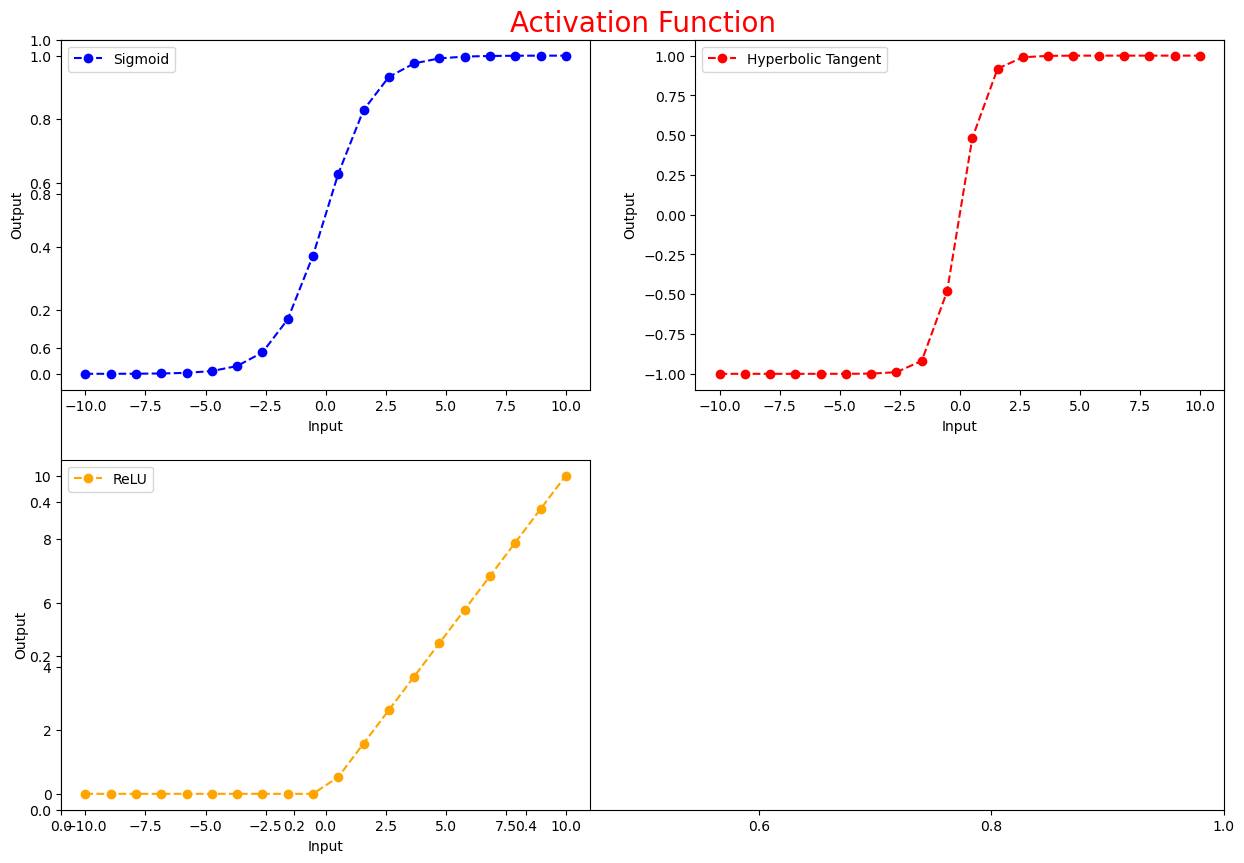

In [21]:
import numpy as np 
import matplotlib.pyplot as mp 

def sigmoid(x): 
    a=1/(1+np.exp(-x)) 
    return a 
def tanhh(x): 
    return np.tanh(x) 
def relu(x): 
    return np.maximum(0,x) 
    
x=np.linspace(-10,10,20)

y=sigmoid(x) 
y1=tanhh(x) 
y2=relu(x) 

mp.figure(figsize=(15,10)) 
mp.title("Activation Function",color="red",fontsize=20) 

mp.subplot(221)

mp.plot(x,y,color="blue",marker="o",linestyle="--",label="Sigmoid") 
mp.xlabel("Input") 
mp.ylabel("Output") 
mp.legend() 

mp.subplot(222) 
mp.plot(x,y1,color="red",marker="o",linestyle="--",label="Hyperbolic Tangent") 
mp.xlabel("Input") 
mp.ylabel("Output") 
mp.legend() 

mp.subplot(223) 
mp.plot(x,y2,color="orange",marker="o",linestyle="--",label="ReLU") 
mp.xlabel("Input") 
mp.ylabel("Output") 
mp.legend() 



In [23]:
# M-P Neuron Implementation
def mp_neuron(x1, x2):
    # Weights: w1 is excitatory (1), w2 is inhibitory (-1)
    w1 = 1
    w2 = -1
    threshold = 1
    
    # Calculate the weighted sum: (x1 * w1) + (x2 * w2)
    net_input = (x1 * w1) + (x2 * w2)
    
    # Threshold Logic
    if net_input >= threshold:
        return 1
    else:
        return 0

# Define the inputs for the ANDNOT truth table
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

print("x1 | x2 | Output")
print("---------------")
for x1, x2 in inputs:
    result = mp_neuron(x1, x2)
    print(f"{x1}  | {x2}  | {result}")

x1 | x2 | Output
---------------
0  | 0  | 0
0  | 1  | 0
1  | 0  | 1
1  | 1  | 0


In [24]:
import numpy as np 
import numpy.random as ar 

def inpt(): 
    b = [] 
    for i in range(10): 
        asc = ord(str(i)) 
        # 'bin' is a built-in function, renamed to 'b_str'
        b_str = format(asc, '07b') 
        print(f"{i} -> {asc} -> {b_str}") 
        d = [int(bit) for bit in b_str] 
        b.append(d) 
    return b 

x = inpt() 
w = ar.rand(7) 
t = [1,0,1,0,1,0,1,0,1,0] # 1 for Even, 0 for Odd
b = 0 
alpha = 0.1 

# Training Phase
for epoch in range(50): 
    e = 0 
    for i in range(len(x)): 
        netw = np.dot(w, x[i]) + b 
        yin = 1 if netw >= 0 else 0 
        error = t[i] - yin 
        if error != 0: 
            e += 1 
            w = w + (alpha * error * np.array(x[i])) 
            b = b + (alpha * error) 
    if e == 0: 
        print(f"Converged at epoch {epoch}")
        break 

print("\nFinal Weights:", w) 
print("Final Bias:", b) 

# Testing Phase
while True: 
    try:
        val = input("\nEnter a single digit (0-9): ")
        asc = ord(val) 
        bin_str = format(asc, '07b') 
        d = [int(bit) for bit in bin_str] 
        netw = np.dot(w, d) + b 
        yin = 1 if netw >= 0 else 0 
        print("Result:", "Even" if yin == 1 else "Odd") 
    except TypeError:
        print("Please enter a valid digit.")
        
    choice = input("Continue? (y/n): ") 
    if choice.lower() != 'y': 
        break

0 -> 48 -> 0110000
1 -> 49 -> 0110001
2 -> 50 -> 0110010
3 -> 51 -> 0110011
4 -> 52 -> 0110100
5 -> 53 -> 0110101
6 -> 54 -> 0110110
7 -> 55 -> 0110111
8 -> 56 -> 0111000
9 -> 57 -> 0111001
Converged at epoch 5

Final Weights: [ 0.95912954  0.57616369 -0.018782    0.43108608  0.09296448  0.21222116
 -0.80300433]
Final Bias: -0.30000000000000004



Enter a single digit (0-9):  3


Result: Odd


Continue? (y/n):  y

Enter a single digit (0-9):  8


Result: Even


Continue? (y/n):  n


Initial w=[0.48049167 0.55065175], b=[0.91617758], lr=[0.0234613]
Converged at epoch: 17
Final weights: [0.12857223 0.15180973]
Final bias: [-0.16304201]
Model is working for all inputs


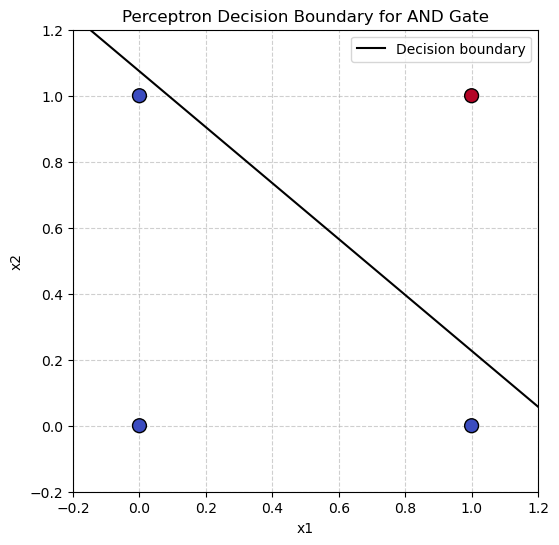

In [3]:
import numpy as np 
import numpy.random as ar 
import matplotlib.pyplot as plt 
 
# Input: [x1, x2] combinations for AND gate
X = np.array([[0,0],[0,1],[1,0],[1,1]]) 
# Target: Only [1,1] results in 1
t = np.array([0,0,0,1]) 

w = ar.rand(2)  
b = ar.rand(1) 
lr = ar.rand(1) 

print(f"Initial w={w}, b={b}, lr={lr}")
 
for epoch in range(50): 
    e = 0 
    for i in range(len(X)): 
        z = np.dot(X[i], w) + b 
        yin_val = 1 if z >= 0 else 0 
        error = t[i] - yin_val 
        if error != 0: 
            e += 1 
            w += lr * error * X[i] 
            b += lr * error 
    if e == 0: 
        print(f"Converged at epoch: {epoch}")
        break

print("Final weights:", w) 
print("Final bias:", b) 
  
# Validation
predictions = [] 
for i in range(len(X)): 
    z = np.dot(X[i], w) + b 
    predictions.append(1 if z >= 0 else 0) 
 
if np.array_equal(predictions, t): 
    print("Model is working for all inputs") 
else: 
    print("Model is not fully correct") 
    print("Predictions:", predictions) 
    print("Targets:", t) 
 
# Visualization
plt.figure(figsize=(6,6)) 
X1 = X[:,0] 
X2 = X[:,1] 

# Plot the data points
plt.scatter(X1, X2, c=t, cmap="coolwarm", edgecolors="k", s=100, zorder=3) 

# Decision Boundary: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
x1_range = np.linspace(-0.5, 1.5, 100) 
x2_boundary = -(x1_range * w[0] + b) / w[1] 

plt.plot(x1_range, x2_boundary, c="black", label="Decision boundary") 

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1") 
plt.ylabel("x2") 
plt.title("Perceptron Decision Boundary for AND Gate") 
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() # Crucial to actually see the plot!

In [41]:
import numpy as np

# 1. Define Orthogonal Pattern Pairs
# We change the last bit of x2 to -1 so x1 and x2 are complete opposites
x1 = np.array([1, 1, 1])
y1 = np.array([1, 1, -1, -1])

x2 = np.array([-1, -1, -1]) # Changed from 1 to -1
y2 = np.array([-1, -1, 1, 1])

# 2. Calculate Weight Matrix
W = np.outer(x1, y1) + np.outer(x2, y2)

print("Weight Matrix (W):\n", W)

# 3. Recall Functions
def recall_forward(x, weight_matrix):
    # np.sign(0) is 0, but in BAM we usually want to maintain 
    # the previous state or push it to 1/-1. 
    # Here we'll just use sign and see the result.
    return np.sign(np.dot(x, weight_matrix))

def recall_backward(y, weight_matrix):
    return np.sign(np.dot(y, weight_matrix.T))

# 4. Execute Recall
y1_res = recall_forward(x1, W)
y2_res = recall_forward(x2, W)
x1_res = recall_backward(y1, W)
x2_res = recall_backward(y2, W)

# 5. Neat Output
print("\n--- RESULTS ---")
print(f"Forward x1 -> y1: {np.array_equal(y1_res, y1)} ({y1_res})")
print(f"Forward x2 -> y2: {np.array_equal(y2_res, y2)} ({y2_res})")
print(f"Backward y1 -> x1: {np.array_equal(x1_res, x1)} ({x1_res})")
print(f"Backward y2 -> x2: {np.array_equal(x2_res, x2)} ({x2_res})")

if all([np.array_equal(y1_res, y1), np.array_equal(x1_res, x1)]):
    print("\nStatus: Success! Perfect bidirectional recall.")

Weight Matrix (W):
 [[ 2  2 -2 -2]
 [ 2  2 -2 -2]
 [ 2  2 -2 -2]]

--- RESULTS ---
Forward x1 -> y1: True ([ 1  1 -1 -1])
Forward x2 -> y2: True ([-1 -1  1  1])
Backward y1 -> x1: True ([1 1 1])
Backward y2 -> x2: True ([-1 -1 -1])

Status: Success! Perfect bidirectional recall.


In [48]:
# 6,7,9

import numpy as np 
import numpy.random as ar 

# XOR Data
X = np.array([[0,0],[0,1],[1,0],[1,1]]) 
Y = np.array([[0],[1],[1],[0]]) 
lr = 0.5 
#np.random.seed(0) 

# Initialize Weights
W1 = ar.rand(2,2) # Weights from Input to Hidden
W2 = ar.rand(2,1) # Weights from Hidden to Output

def sigmoid(x): 
    return 1 / (1 + np.exp(-x)) 

def sigmoid_d(x): 
    return x * (1 - x) 

print("Training started...")

for i in range(3001): 
    # --- FORWARD PASS ---
    hidden_input = np.dot(X, W1) 
    hidden_output = sigmoid(hidden_input) 
    
    final_input = np.dot(hidden_output, W2) 
    final_output = sigmoid(final_input) 

    # --- BACKPROPAGATION ---
    # 1. Calculate error at Output
    error = Y - final_output 
    d_output = error * sigmoid_d(final_output) 
    
    # 2. Calculate error at Hidden Layer
    error_hidden = np.dot(d_output, W2.T)
    d_hidden = error_hidden * sigmoid_d(hidden_output) 

    # --- WEIGHT UPDATE (This MUST be inside the loop) ---
    W2 += np.dot(hidden_output.T, d_output) * lr 
    W1 += np.dot(X.T, d_hidden) * lr 

    # Print progress
    if i % 500 == 0: 
        mse = np.mean(np.square(error))
        print(f"Epoch: {i} | MSE: {mse:.4f}")

print("\n***************** FINAL OUTPUT *******************")
# Threshold the final results to 0 or 1
final_results = np.array([[1 if val > 0.5 else 0] for val in final_output])
print("Predicted XOR Output:\n", final_results)

print("\n***************** FINAL WEIGHTS *******************")
print("W1 (Input-Hidden):\n", W1)
print("W2 (Hidden-Output):\n", W2)

Training started...
Epoch: 0 | MSE: 0.2595
Epoch: 500 | MSE: 0.2206
Epoch: 1000 | MSE: 0.1384
Epoch: 1500 | MSE: 0.0936
Epoch: 2000 | MSE: 0.0686
Epoch: 2500 | MSE: 0.0532
Epoch: 3000 | MSE: 0.0430

***************** FINAL OUTPUT *******************
Predicted XOR Output:
 [[0]
 [1]
 [1]
 [0]]

***************** FINAL WEIGHTS *******************
W1 (Input-Hidden):
 [[0.83727999 6.27560138]
 [0.83730338 6.27869197]]
W2 (Hidden-Output):
 [[-16.71520041]
 [ 13.0612154 ]]


In [54]:
import numpy as np

# 1. Inputs (4-bit binary patterns)
patterns = [
    np.array([1, 1, 0, 0]),
    np.array([1, 1, 0, 1]),
    np.array([0, 0, 1, 1]),
    np.array([0, 0, 1, 0])
]

vigilance = 0.6
weights = []   # Cluster templates
clusters = []  # Grouped patterns

# 2. Clustering Loop
for p in patterns:
    found = False  #flag
    
    for i in range(len(weights)):
        # Calculate Match: (Intersection / Total bits in input)
        match = np.sum(np.minimum(p, weights[i])) / np.sum(p)
        
        if match >= vigilance:
            # RESONANCE: Join existing cluster and update template
            weights[i] = np.minimum(weights[i], p)
            clusters[i].append(p.tolist())
            found = True
            break
            
    if not found:
        # RESET: Create a new cluster
        weights.append(p)
        clusters.append([p.tolist()])

# 3. Output
for i in range(len(clusters)):
    print(f"Cluster {i}: {clusters[i]}")

Cluster 0: [[1, 1, 0, 0], [1, 1, 0, 1]]
Cluster 1: [[0, 0, 1, 1], [0, 0, 1, 0]]


In [96]:
import numpy as np

# 1. Stored Patterns (Orthogonal / Highly Distinct)
# To work well, patterns should have a dot product of 0 or close to it.
P = np.array([
    [1, 1, -1, -1],  # Pattern A
    [1, -1, 1, -1]   # Pattern B
])

# 2. Training: Create Weight Matrix
W = np.dot(P.T, P)
np.fill_diagonal(W, 0)

print("New Weight Matrix:\n", W)

# 3. Testing: Noisy Inputs
# N1 is a corrupted version of Pattern A
# N2 is a corrupted version of Pattern B
N = np.array([
    [1, 1, 1, -1],   # Only one bit off from Pattern A
    [1, -1, -1, -1]  # Only one bit off from Pattern B
])

def recall(noisy_pattern, weights, steps=2):
    state = noisy_pattern
    for _ in range(steps): # Iterative recall is more stable
        raw_output = np.dot(weights, state)
        state = np.where(raw_output >= 0, 1, -1)
    return state

print("\n--- FIXED RECALL RESULTS ---")
for i in range(len(N)):
    recalled = recall(N[i], W)
    print(f"Noisy Input: {N[i]} -> Recalled: {recalled}")

New Weight Matrix:
 [[ 0  0  0 -2]
 [ 0  0 -2  0]
 [ 0 -2  0  0]
 [-2  0  0  0]]

--- FIXED RECALL RESULTS ---
Noisy Input: [ 1  1  1 -1] -> Recalled: [ 1  1  1 -1]
Noisy Input: [ 1 -1 -1 -1] -> Recalled: [ 1 -1 -1 -1]


In [98]:
import tensorflow as tf 
import numpy as np 
# Data 
x = np.array([1,2,3,4,5,6,7,8,9], dtype=float) 
y = np.array([0,0,0,0,1,1,1,1,1], dtype=float) 
# Model 
model = tf.keras.Sequential([ 
tf.keras.Input(shape=(1,)), 
tf.keras.layers.Dense(1, activation='sigmoid') 
]) 
# Compile 
model.compile( 
optimizer='adam', 
loss='binary_crossentropy', 
metrics=['accuracy'] 
) 
# Train 
model.fit(x, y, epochs=2000, verbose=0) 
# Predictions 
pred_5 = model.predict(np.array([[5]])) 
pred_3 = model.predict(np.array([[3]])) 
pred_9 = model.predict(np.array([[9]])) 
pred_0 = model.predict(np.array([[0]])) 
pred_10 = model.predict(np.array([[10]])) 
# Print results 
print("For 5 hours:") 
print("Probability:", pred_5[0][0]) 
print("Result:", "Pass" if pred_5[0][0] >= 0.5 else "Fail") 
print("\nFor 3 hours:") 
print("Probability:", pred_3[0][0]) 
print("Result:", "Pass" if pred_3[0][0] >= 0.5 else "Fail") 
print("\nFor 9 hours:") 
print("Probability:", pred_9[0][0]) 
print("Result:", "Pass" if pred_9[0][0] >= 0.5 else "Fail") 
print("\nFor 0 hours:") 
print("Probability:", pred_0[0][0]) 
print("Result:", "Pass" if pred_0[0][0] >= 0.5 else "Fail") 
print("\nFor 10 hours:") 
print("Probability:", pred_10[0][0]) 
print("Result:", "Pass" if pred_10[0][0] >= 0.5 else "Fail") 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
For 5 hours:
Probability: 0.7046069
Result: Pass

For 3 hours:
Probability: 0.6760747
Result: Pass

For 9 hours:
Probability: 0.75702125
Result: Pass

For 0 hours:
Probability: 0.6307597
Result: Pass

For 10 hours:
Probability: 0.7690915
Result: Pass


In [99]:
import tensorflow as tf 
from tensorflow.keras import layers, models 
from tensorflow.keras.utils import to_categorical 
 
# 1. Load Dataset 
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data() 
 
# 2. Preprocess Data 
 
# Normalize (0–255 → 0–1) 
x_train = x_train / 255.0 
x_test = x_test / 255.0 
 
# Reshape for CNN (add channel dimension) 
x_train = x_train.reshape(-1, 28, 28, 1) 
x_test = x_test.reshape(-1, 28, 28, 1) 
 
# One-hot encoding of labels 
y_train = to_categorical(y_train, 10) 
y_test = to_categorical(y_test, 10) 
 
# 3. Design CNN Architecture 
model = models.Sequential([ 
 
    # Input + Conv + ReLU + Pool 
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)), 
    layers.MaxPooling2D((2,2)), 
 
    # Conv + ReLU + Pool 
    layers.Conv2D(64, (3,3), activation='relu'), 
    layers.MaxPooling2D((2,2)), 
 
    # Flatten 
    layers.Flatten(), 
 
    # Fully Connected Layer 
    layers.Dense(64, activation='relu'), 
 
    # Output Layer 
    layers.Dense(10, activation='softmax') 
]) 
 
# 4. Compile Model 
model.compile( 
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy'] 
) 
# 5. Train Model 
model.fit(x_train, y_train, epochs=5, batch_size=32) 
# 6. Evaluate Model 
test_loss, test_acc = model.evaluate(x_test, y_test) 
print("Test Accuracy:", test_acc) 
# 7. Prediction 
predictions = model.predict(x_test) 
print("Predicted Label:", predictions[0].argmax()) 
print("Actual Label:", y_test[0].argmax())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step 


C:\Users\Om Salave\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9560 - loss: 0.1451
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9857 - loss: 0.0469
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9895 - loss: 0.0332
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9923 - loss: 0.0246
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9938 - loss: 0.0188
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9909 - loss: 0.0314
Test Accuracy: 0.9908999800682068
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicted Label: 7
Actual Label: 7


Loading and preprocessing data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 31s 0us/step 

--- Training Baseline Model ---
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.4898 - loss: 1.4331 - val_accuracy: 0.5843 - val_loss: 1.1828
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.6239 - loss: 1.0788 - val_accuracy: 0.6203 - val_loss: 1.0621
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6696 - loss: 0.9529 - val_accuracy: 0.6742 - val_loss: 0.9460
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7017 - loss: 0.8664 - val_accuracy: 0.6773 - val_loss: 0.9393
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7195 - loss: 0.8041 - val_accuracy: 0.6876 - val_loss: 0.9153
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7409 - loss: 0.7408 - val_accuracy: 0.6999 - val_loss: 0.9008
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7563 - loss: 0.6

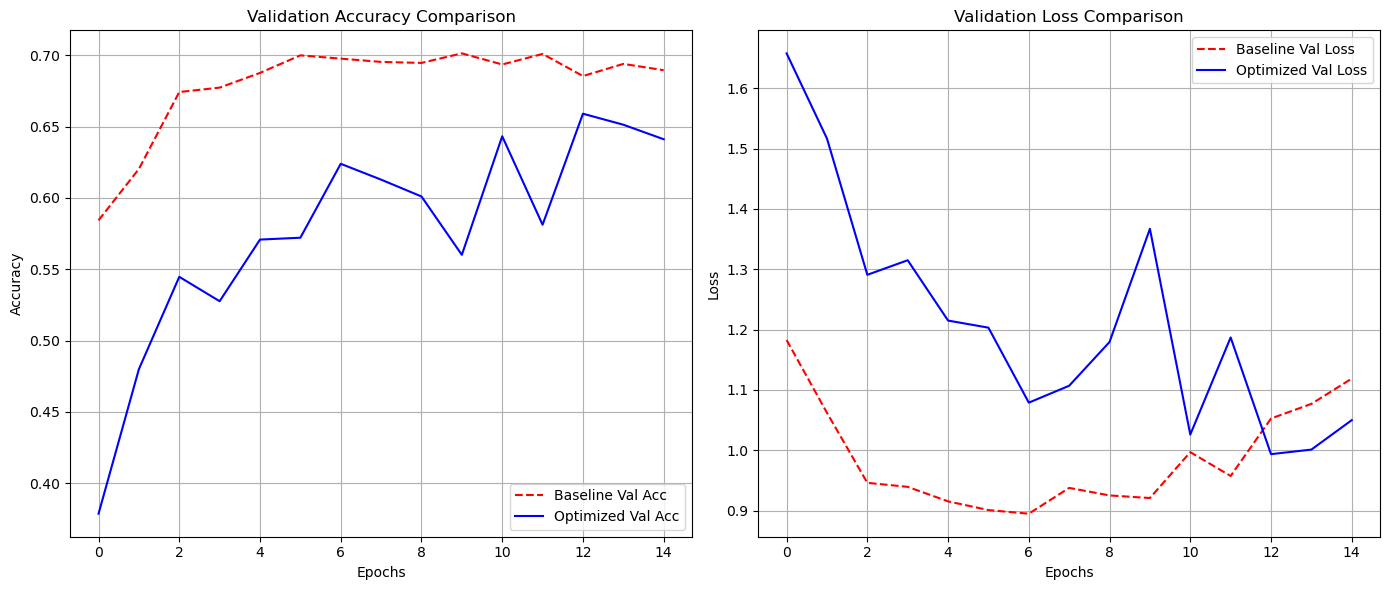

In [101]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. DATA PREPARATION
print("Loading and preprocessing data...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# 2. BASELINE MODEL (Prone to overfitting)
def build_baseline():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10)
    ])
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

# 3. OPTIMIZED MODEL (Hyperparameter Tuning: Augmentation, Dropout, Batch Normalization)
def build_optimized():
    model = models.Sequential([
        # Data Augmentation to prevent overfitting
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(), # Stabilizes learning
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3), # Reduces co-dependency of neurons
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Regularization for the dense layer
        layers.Dense(10)
    ])
    
    # Using a specific learning rate for better convergence
    opt = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt,
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

# 4. TRAINING
EPOCHS = 15

print("\n--- Training Baseline Model ---")
baseline_model = build_baseline()
history_base = baseline_model.fit(train_images, train_labels, epochs=EPOCHS, 
                                  validation_data=(test_images, test_labels), verbose=1)

print("\n--- Training Optimized Model ---")
optimized_model = build_optimized()
history_opt = optimized_model.fit(train_images, train_labels, epochs=EPOCHS, 
                                  validation_data=(test_images, test_labels), verbose=1)

# 5. VISUALIZATION OF COMPARISONS
def plot_results(h_base, h_opt):
    epochs_range = range(EPOCHS)

    plt.figure(figsize=(14, 6))

    # Accuracy Comparison
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, h_base.history['val_accuracy'], label='Baseline Val Acc', color='red', linestyle='--')
    plt.plot(epochs_range, h_opt.history['val_accuracy'], label='Optimized Val Acc', color='blue')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Loss Comparison
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, h_base.history['val_loss'], label='Baseline Val Loss', color='red', linestyle='--')
    plt.plot(epochs_range, h_opt.history['val_loss'], label='Optimized Val Loss', color='blue')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_results(history_base, history_opt)